# Hafta 1: Biyoenformatiğe Giriş, Moleküler Biyoloji Temelleri ve Çalışma Ortamı

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Biyoenformatiğin neyle uğraştığını ve bilgisayar mühendisliğiyle bağlantısını kavramak.
2. DNA, RNA ve protein kavramlarını *veri yapısı* gözüyle anlamak (alfabe, uzunluk, yön).
3. Colab ortamını ve Python'un temel dizgi (string) işlemlerini biyolojik dizilere uygulamak.
4. Biopython'u kurmak, modül haritasını tanımak ve ilk `Seq` nesnesini oluşturmak.

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


## 1. Biyoenformatik nedir?

Biyoenformatik; biyolojik verinin (dizi, yapı, ifade, etkileşim) **saklanması, işlenmesi, analizi ve yorumlanması** için
bilgisayar bilimi, istatistik ve biyolojiyi birleştiren disiplindir.

| Alt alan | Tipik soru | Bilgisayar bilimi karşılığı |
|---|---|---|
| Dizi analizi | Bu gen hangi proteini kodluyor? | Dizgi işleme, sonlu otomatlar |
| Dizi hizalama | İki gen ne kadar benzer? | Dinamik programlama |
| Veritabanı arama (BLAST) | Bu diziye benzeyen diziler hangileri? | İndeksleme, sezgisel arama |
| Filogenetik | Türler arasındaki akrabalık nasıl? | Ağaç veri yapıları, kümeleme |
| Yapısal biyoinformatik | Protein 3B'de nasıl katlanıyor? | Geometri, optimizasyon |
| Fonksiyonel genomik | Hangi genler hastalıkta farklı ifade ediliyor? | İstatistik, makine öğrenmesi |

## 2. Biyolojik diziler = bir alfabe üzerindeki dizgiler

| Molekül | Alfabe | Boyut | Örnek |
|---|---|---|---|
| DNA | {A, C, G, T} | 4 | `ATGGCGTAA` |
| RNA | {A, C, G, U} | 4 | `AUGGCGUAA` |
| Protein | 20 standart amino asit | 20 | `MA*` (`*` = dur kodonu) |

**Merkezi dogma:** DNA —(replikasyon)→ DNA, DNA —(transkripsiyon)→ RNA —(translasyon)→ Protein.

* DNA çift sarmallıdır; iplikler **ters yönlü (antiparalel)** ve **tamamlayıcıdır**: A↔T, G↔C.
* Diziler geleneksel olarak **5'→3'** yönünde yazılır.
* Üç nükleotit (kodon) bir amino asidi kodlar → 4³ = 64 kodon, 20 amino asit + 3 dur kodonu.

## 3. Saf Python ile dizi işlemleri (Biopython'dan önce)
Önce hiçbir kütüphane kullanmadan temel işlemleri yazalım; böylece Biopython'un arka planda ne yaptığını anlarız.

In [2]:
dna = "ATGGCGTACGTTAGCCTAGGCTAA"
print("Uzunluk:", len(dna))
print("İlk kodon:", dna[:3], "| Son kodon:", dna[-3:])

# Baz sayımı: sözlük (dict) ile
sayim = {}
for baz in dna:
    sayim[baz] = sayim.get(baz, 0) + 1
print("Baz sayıları:", sayim)

# Aynı işi collections.Counter ile
from collections import Counter
print("Counter:", Counter(dna))

Uzunluk: 24
İlk kodon: ATG | Son kodon: TAA
Baz sayıları: {'A': 6, 'T': 6, 'G': 7, 'C': 5}
Counter: Counter({'G': 7, 'A': 6, 'T': 6, 'C': 5})


In [3]:
def gc_orani(dizi):
    '''G ve C bazlarının oranı (0-1 arası).'''
    dizi = dizi.upper()
    return (dizi.count("G") + dizi.count("C")) / len(dizi)

def tamamlayici(dizi):
    eslesme = {"A": "T", "T": "A", "G": "C", "C": "G"}
    return "".join(eslesme[b] for b in dizi)

def ters_tamamlayici(dizi):
    return tamamlayici(dizi)[::-1]

print("GC oranı       :", round(gc_orani(dna), 3))
print("Tamamlayıcı    :", tamamlayici(dna))
print("Ters tamamlayıcı:", ters_tamamlayici(dna))
print("Transkript (RNA):", dna.replace("T", "U"))

GC oranı       : 0.5
Tamamlayıcı    : TACCGCATGCAATCGGATCCGATT
Ters tamamlayıcı: TTAGCCTAGGCTAACGTACGCCAT
Transkript (RNA): AUGGCGUACGUUAGCCUAGGCUAA


### Sayısal örnek 1 — Ters tamamlayıcıyı elle bulma
`5'-ATGCC-3'` dizisinin ters tamamlayıcısı:

| Adım | Sonuç |
|---|---|
| Tamamlayıcı (A↔T, G↔C) | `TACGG` (3'→5' okunur) |
| Ters çevir (5'→3' yazmak için) | `GGCAT` |

Kodla kontrol edelim:

In [4]:
print(ters_tamamlayici("ATGCC"))   # beklenen: GGCAT

GGCAT


### Sayısal örnek 2 — Bir motif rastgele bir genomda kaç kez beklenir?
Bazların eşit olasılıklı (p = 1/4) ve bağımsız olduğunu varsayalım.
Belirli bir *k*-merin herhangi bir konumda görülme olasılığı $p = (1/4)^k$.
Uzunluğu *N* olan bir dizide yaklaşık $N-k+1$ konum vardır, beklenen sayı: $E = (N-k+1)\cdot(1/4)^k$.

**Soru:** EcoRI enziminin tanıma dizisi `GAATTC` (k = 6). 4 639 675 bp'lik *E. coli* genomunda (tek iplik) kaç kez beklenir?

$E = (4\,639\,675 - 5) / 4^6 = 4\,639\,670 / 4096 \approx 1132.7$

EcoRI palindromik olduğundan (ters tamamlayıcısı kendisi) iki ipliği ayrı saymaya gerek yoktur.

In [5]:
N, k = 4_639_675, 6
E = (N - k + 1) / 4**k
print(f"Beklenen EcoRI yeri sayısı ≈ {E:.1f}")
print(f"Ortalama parça uzunluğu ≈ {4**k} bp")

# Simülasyonla doğrulayalım (daha kısa rastgele bir dizi ile)
import random
random.seed(0)
n_sim = 1_000_000
rastgele = "".join(random.choices("ACGT", k=n_sim))
gozlenen = sum(1 for i in range(n_sim - 5) if rastgele[i:i+6] == "GAATTC")
print("1 Mbp rastgele dizide gözlenen:", gozlenen, "| beklenen:", round((n_sim - 5) / 4096, 1))

Beklenen EcoRI yeri sayısı ≈ 1132.7
Ortalama parça uzunluğu ≈ 4096 bp


1 Mbp rastgele dizide gözlenen: 251 | beklenen: 244.1


### Sayısal örnek 3 — Genomun bilgisayar belleğindeki boyutu
Her baz 4 olasılıktan biridir → $\log_2 4 = 2$ bit.
İnsan genomu ≈ 3.1 × 10⁹ baz → $3.1\times10^9 \times 2 / 8 \approx 775$ MB (2-bit kodlama).
Düz metin (1 bayt/baz, ASCII) olarak ise ≈ 3.1 GB.

In [6]:
insan = 3.1e9
print(f"2-bit kodlama : {insan*2/8/1e6:,.0f} MB")
print(f"ASCII (8 bit) : {insan/1e9:,.1f} GB")

# 2-bit kodlamayı küçük bir dizide deneyelim
kod = {"A": 0b00, "C": 0b01, "G": 0b10, "T": 0b11}
def paketle(dizi):
    sayi = 0
    for b in dizi:
        sayi = (sayi << 2) | kod[b]
    return sayi
x = paketle("GATTACA")
print("GATTACA ->", bin(x), "=", x)

2-bit kodlama : 775 MB
ASCII (8 bit) : 3.1 GB
GATTACA -> 0b10001111000100 = 9156


## 4. Colab ile çalışmak

* **Dosya yükleme:** Sol paneldeki klasör simgesi → *Yükle*, ya da kodla:
```python
from google.colab import files
yuklenen = files.upload()
```
* **Google Drive bağlama:**
```python
from google.colab import drive
drive.mount('/content/drive')
```
* `!` ile başlayan satırlar kabuk (shell) komutudur: `!ls`, `!pip install ...`
* Oturum kapandığında dosyalar silinir; kalıcı dosyaları Drive'a kaydedin.

In [7]:
import sys, platform
print("Python:", sys.version.split()[0], "|", platform.system())
!ls -la | head

Python: 3.11.15 | Linux


total 12
drwxr-xr-x  3 root root 4096 Sep 23 10:21 .
drwxr-xr-x 17 root root 4096 Sep 23 10:21 ..
drwxr-xr-x  2 root root 4096 Sep 23 10:21 veri


## 5. Biopython'a ilk bakış

| Modül | Görevi | Ders haftası |
|---|---|---|
| `Bio.Seq`, `Bio.SeqRecord` | Dizi nesneleri ve açıklamalı kayıtlar | 2–3 |
| `Bio.SeqIO` | FASTA/GenBank/FASTQ okuma-yazma | 3–4 |
| `Bio.SeqUtils`, `Bio.Restriction`, `Bio.motifs` | Dizi analiz araçları | 5 |
| `Bio.Align` | İkili ve çoklu hizalama | 6–7, 9 |
| `Bio.Entrez`, `Bio.Blast` | NCBI erişimi, BLAST | 8 |
| `Bio.Phylo` | Filogenetik ağaçlar | 9 |
| `Bio.PDB` | Protein 3B yapıları | 10 |

In [8]:
from Bio.Seq import Seq

s = Seq("ATGGCGTACGTTAGCCTAGGCTAA")
print(type(s))
print("Ters tamamlayıcı:", s.reverse_complement())
print("Transkripsiyon   :", s.transcribe())
print("Translasyon      :", s.translate())
print("to_stop=True     :", s.translate(to_stop=True))

<class 'Bio.Seq.Seq'>
Ters tamamlayıcı: TTAGCCTAGGCTAACGTACGCCAT
Transkripsiyon   : AUGGCGUACGUUAGCCUAGGCUAA
Translasyon      : MAYVSLG*
to_stop=True     : MAYVSLG


Saf Python fonksiyonlarımızla Biopython'un sonuçlarını karşılaştıralım (birim test mantığı):

In [9]:
assert str(s.reverse_complement()) == ters_tamamlayici(str(s))
assert str(s.transcribe()) == str(s).replace("T", "U")
print("Tüm kontroller başarılı ✔")

Tüm kontroller başarılı ✔


## 6. Küçük bir görselleştirme: baz kompozisyonu

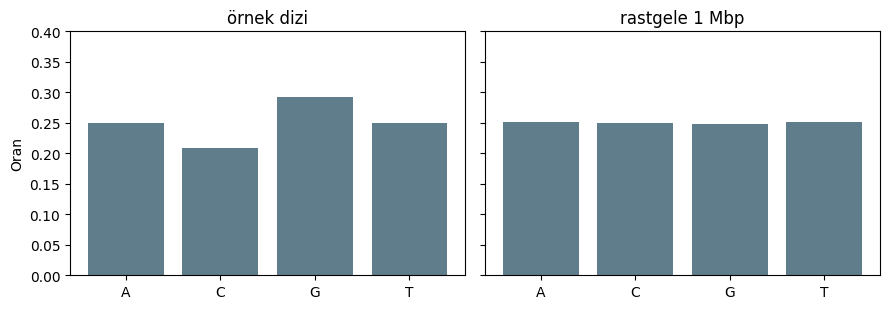

In [10]:
import matplotlib.pyplot as plt

diziler = {"örnek dizi": str(s), "rastgele 1 Mbp": rastgele[:100000]}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, (ad, d) in zip(axes, diziler.items()):
    c = Counter(d)
    bazlar = "ACGT"
    ax.bar(list(bazlar), [c[b] / len(d) for b in bazlar], color="#607d8b")
    ax.set_title(ad); ax.set_ylim(0, 0.4)
axes[0].set_ylabel("Oran")
plt.tight_layout(); plt.show()

## 7. Alıştırmalar
1. `gc_orani` fonksiyonunu, dizide `N` (bilinmeyen baz) varsa bunları paydadan çıkaracak şekilde güncelleyin.
2. Bir DNA dizisinin **palindromik** (ters tamamlayıcısına eşit) olup olmadığını döndüren `palindrom_mu(dizi)` fonksiyonunu yazın.
   `GAATTC`, `GGATCC`, `ATGCAT` ve `ATGCCA` için test edin.
3. 8 bazlık bir tanıma dizisine sahip bir enzim (ör. NotI: `GCGGCCGC`) 3 Gbp'lik rastgele bir genomda kaç kez beklenir?
   Ortalama parça uzunluğu nedir?
4. `paketle` fonksiyonunun tersi olan `ac(sayi, uzunluk)` fonksiyonunu yazın ve `GATTACA` için test edin.

---
## Çözümler

In [11]:
# 1
def gc_orani_n(dizi):
    dizi = dizi.upper()
    gecerli = sum(dizi.count(b) for b in "ACGT")
    return (dizi.count("G") + dizi.count("C")) / gecerli if gecerli else 0.0
print("1)", round(gc_orani_n("GGCCNNAT"), 3))   # 4/6 = 0.667

# 2
def palindrom_mu(dizi):
    return dizi == ters_tamamlayici(dizi)
for d in ["GAATTC", "GGATCC", "ATGCAT", "ATGCCA"]:
    print("2)", d, palindrom_mu(d))

# 3
N = 3e9
print(f"3) Beklenen NotI yeri ≈ {(N - 7) / 4**8:,.0f}, ortalama parça ≈ {4**8:,} bp")

# 4
def ac(sayi, uzunluk):
    harf = "ACGT"
    return "".join(harf[(sayi >> (2 * (uzunluk - 1 - i))) & 0b11] for i in range(uzunluk))
print("4)", ac(paketle("GATTACA"), 7))

1) 0.667
2) GAATTC True
2) GGATCC True
2) ATGCAT True
2) ATGCCA False
3) Beklenen NotI yeri ≈ 45,776, ortalama parça ≈ 65,536 bp
4) GATTACA
